# **Credit Risk Detection Using Classification and Anomaly Detection Techniques**

## **1. Problem Statement**
Goal: Predict whether a customer is high-risk (TARGET=1) or low-risk (TARGET=0).

## **2.Import Libraries**


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest

from imblearn.over_sampling import SMOTE

## **3. Load Dataset**

In [5]:
from google.colab import files
df = files.upload()


Saving credit_dataset.csv to credit_dataset.csv


In [6]:
df = pd.read_csv('credit_dataset.csv')
df.head()

,Unnamed: 0,ID,GENDER,CAR,REALITY,NO_OF_CHILD,INCOME,INCOME_TYPE,EDUCATION_TYPE,FAMILY_TYPE,HOUSE_TYPE,FLAG_MOBIL,WORK_PHONE,PHONE,E_MAIL,FAMILY SIZE,BEGIN_MONTH,AGE,YEARS_EMPLOYED,TARGET
0,0,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,2.0,29,59,3,0
1,1,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,1.0,4,52,8,0
2,2,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,1.0,26,52,8,0
3,3,5008810,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,1.0,26,52,8,0
4,4,5008811,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,1.0,38,52,8,0


## **4. Data Exploration**

In [7]:
df.shape

(25134, 20)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25134 entries, 0 to 25133
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      25134 non-null  int64  
 1   ID              25134 non-null  int64  
 2   GENDER          25134 non-null  object 
 3   CAR             25134 non-null  object 
 4   REALITY         25134 non-null  object 
 5   NO_OF_CHILD     25134 non-null  int64  
 6   INCOME          25134 non-null  float64
 7   INCOME_TYPE     25134 non-null  object 
 8   EDUCATION_TYPE  25134 non-null  object 
 9   FAMILY_TYPE     25134 non-null  object 
 10  HOUSE_TYPE      25134 non-null  object 
 11  FLAG_MOBIL      25134 non-null  int64  
 12  WORK_PHONE      25134 non-null  int64  
 13  PHONE           25134 non-null  int64  
 14  E_MAIL          25134 non-null  int64  
 15  FAMILY SIZE     25134 non-null  float64
 16  BEGIN_MONTH     25134 non-null  int64  
 17  AGE             25134 non-null 

In [9]:
df.describe()

,Unnamed: 0,ID,NO_OF_CHILD,INCOME,FLAG_MOBIL,WORK_PHONE,PHONE,E_MAIL,FAMILY SIZE,BEGIN_MONTH,AGE,YEARS_EMPLOYED,TARGET
count,25134.000000,2.513400e+04,25134.000000,2.513400e+04,25134.0,25134.000000,25134.000000,25134.000000,25134.000000,25134.000000,25134.000000,25134.000000,25134.000000
mean,12566.500000,5.078838e+06,0.512334,1.948339e+05,1.0,0.273812,0.292791,0.100660,2.294064,26.120594,40.536166,7.204106,0.016790
std,7255.705169,4.194102e+04,0.787785,1.045110e+05,0.0,0.445923,0.455052,0.300885,0.947590,16.439658,9.559474,6.414231,0.128486
min,0.000000,5.008806e+06,0.000000,2.700000e+04,1.0,0.000000,0.000000,0.000000,1.000000,0.000000,21.000000,0.000000,0.000000
25%,6283.250000,5.042228e+06,0.000000,1.350000e+05,1.0,0.000000,0.000000,0.000000,2.000000,12.000000,33.000000,3.000000,0.000000
50%,12566.500000,5.079004e+06,0.000000,1.800000e+05,1.0,0.000000,0.000000,0.000000,2.000000,24.000000,40.000000,5.000000,0.000000
75%,18849.750000,5.115604e+06,1.000000,2.250000e+05,1.0,1.000000,1.000000,0.000000,3.000000,39.000000,48.000000,10.000000,0.000000
max,25133.000000,5.150487e+06,19.000000,1.575000e+06,1.0,1.000000,1.000000,1.000000,20.000000,60.000000,67.000000,43.000000,1.000000


### **3. Check Fraud Distribution**

In [10]:
df['TARGET'].value_counts()

,count
TARGET,
0,24712
1,422


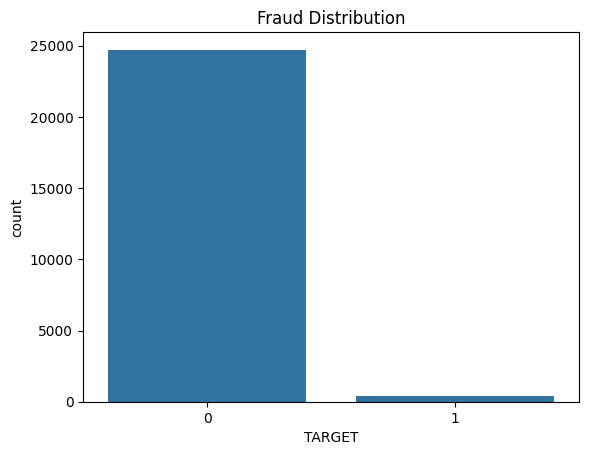

In [11]:
sns.countplot(x='TARGET', data=df)
plt.title('Fraud Distribution')
plt.show()

## **4.Separate Features and Target**

In [12]:
x = df.drop('TARGET', axis=1)
y = df['TARGET']

## **5. Convert Categorical Columns**

In [13]:
x.dtypes

,0
Unnamed: 0,int64
ID,int64
GENDER,object
CAR,object
REALITY,object
NO_OF_CHILD,int64
INCOME,float64
INCOME_TYPE,object
EDUCATION_TYPE,object
FAMILY_TYPE,object


In [14]:
x = pd.get_dummies(x, drop_first=True)

## **6. Handle Missing Values**

In [15]:
x = x.fillna(x.median())

## **7. Train-Test Split**

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## **8. Feature Scaling**

In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## **9. Handle Class Imbalance using SMOTE**

**Checking imbalance**

In [18]:
y_train.value_counts()

,count
TARGET,
0,19769
1,338


**Applying SMOTE**

In [19]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

**Checking new distribution**

In [20]:
pd.Series(y_train_smote).value_counts()

,count
TARGET,
0,19769
1,19769


## **MODEL 1: Logistic Regression**

## **10. Train Model**

In [21]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000)

## **11. Predictions**

In [22]:
y_prob = lr.predict_proba(X_test)[:,1]

**To reduce false positives:**

In [23]:
threshold = 0.60

y_pred = (y_prob >= threshold).astype(int)

## **12. Evaluation**

**ROC-AUC**

In [24]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC AUC:", roc_auc)

ROC AUC: 0.8827273778214503


**Confusion Matrix**

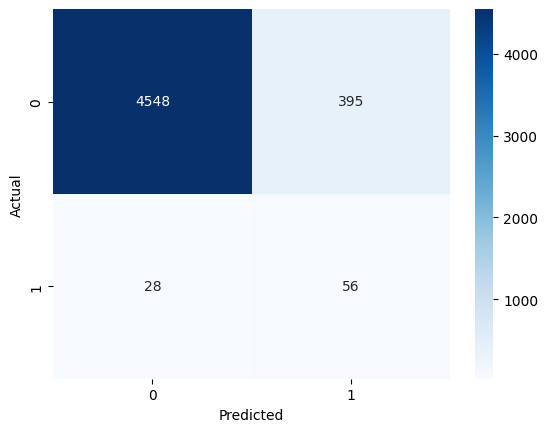

In [25]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Classification Report**

In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.92      0.96      4943
           1       0.12      0.67      0.21        84

    accuracy                           0.92      5027
   macro avg       0.56      0.79      0.58      5027
weighted avg       0.98      0.92      0.94      5027



## **13. ROC Curve**

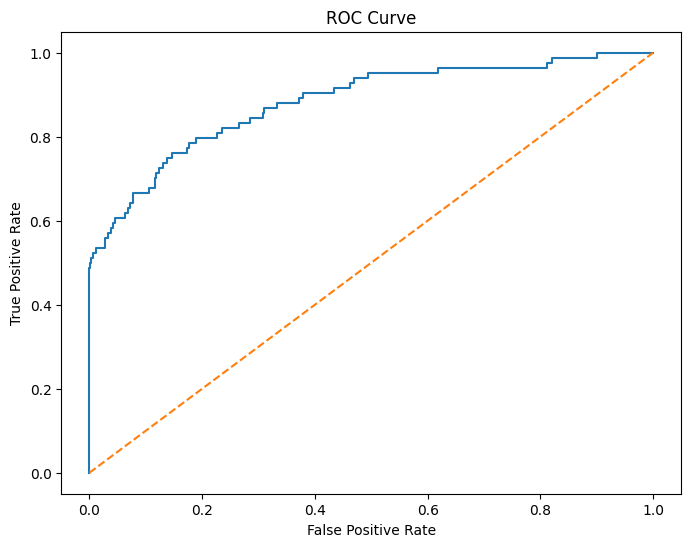

In [27]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve')
plt.show()

## **MODEL 2: Isolation Forest**

**Isolation Forest is an anomaly detector.**

## **14. Train Isolation Forest**

In [28]:
iso = IsolationForest(
    contamination=0.02,
    random_state=42
)

iso.fit(X_train)

IsolationForest(contamination=0.02, random_state=42)

## **15. Predict Anomalies**

In [29]:
iso_scores = -iso.score_samples(X_test)

**ROC-AUC:**

In [30]:
print(
    "Isolation Forest ROC AUC:",
    roc_auc_score(
        y_test,
        iso_scores
    )
)

Isolation Forest ROC AUC: 0.5196405691550341


## **16. Confusion Matrix**

In [31]:
iso_pred = (
    iso.predict(X_test) == -1
).astype(int)

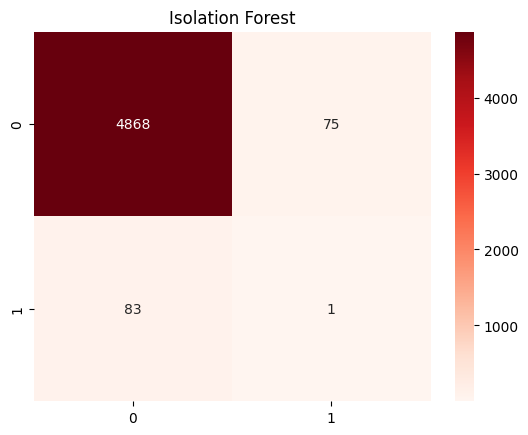

In [32]:
cm = confusion_matrix(
    y_test,
    iso_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title("Isolation Forest")
plt.show()

## **17. Compare Models**

In [34]:
results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Isolation Forest'
    ],
    'ROC_AUC':[
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, iso_scores)
    ]
})

print(results)

                 Model   ROC_AUC
0  Logistic Regression  0.882727
1     Isolation Forest  0.519641


## **18. Predict New Transaction**

In [35]:
sample = X_test[0].reshape(1,-1)

In [36]:
fraud_probability = lr.predict_proba(sample)[0][1]

print("Fraud Probability:", fraud_probability)

Fraud Probability: 0.19111222755089297


In [37]:
if fraud_probability >= 0.60:
    print("Fraud Transaction")
else:
    print("Legitimate Transaction")

Legitimate Transaction
